# WIP: Find a way to make it possible to read in provedIt data and have an existing model make predictions?

In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from DNAnet.data.data_models import Panel
from DNAnet.data.data_models.custom_hid_dataset import CustomHIDDataset
from DNAnet.data.parsing.file_categorization_strategy import ProvedItFileCategorizer
from DNAnet.data.validation.sample_validation_strategy import NFIValidationStrategy
from DNAnet.data.kit_compatibility.lane_standards import InternalSizeStandard


from typing import List
from pathlib import Path

# Create HID Dataset

In [3]:
gf_panel_path = "resources/data/ProvedIt/SGPanel_Globalfiler_Panel.xml"
hid_files_path = "/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles"
reference_genotype_path = "/Users/amarmesic/Documents/tudelft/thesis/DNANet/resources/data/ProvedIt/References"
file_categorizer = ProvedItFileCategorizer()
sample_validator = NFIValidationStrategy()

In [4]:
images = CustomHIDDataset(
    root_path=hid_files_path,
    panel_path=gf_panel_path,
    size_standard=InternalSizeStandard.GENESCAN_600_LIZ.value,
    file_categorization_strategy=file_categorizer,
    sample_validation_strategy=sample_validator,
)

In [5]:
len(images.sample_files), len(images)

(675, 518)

In [20]:
from DNAnet.models.base import Model
from config_io import load_model

unet_model = load_model("config/models/unet.yaml")
# unet_model.load("resources/model/current_best_unet/")
unet_model.load("./best_model_analysis/")

# what if we use predict() singularly?
predictions = unet_model.predict_batch(images)

2025-07-29 15:05:48 INFO     Calling alleles from predicted segmentation...
2025-07-29 15:05:50 WARNING  No predictions present in dye row 0
2025-07-29 15:05:50 WARNING  No predictions present in dye row 1


In [21]:
len(predictions)

518

In [22]:
from DNAnet.evaluation.segmentation.allele_metrics import allele_f1_score, allele_precision, allele_recall
from DNAnet.evaluation.segmentation.pixel_metrics import pixel_f1_score, pixel_precision, pixel_recall

# the metric functions rely on a sequence, so we can make singletons
print('allele u-net f1: ', allele_f1_score(images, predictions))
print('allele u-net precision: ', allele_precision(images, predictions))
print('allele u-net recall: ', allele_recall(images, predictions))

allele u-net f1:  0.9064346804683772
allele u-net precision:  0.979713288192975
allele u-net precision:  0.979713288192975
allele u-net recall:  0.8433551148653263
allele u-net recall:  0.8433551148653263


In [36]:
# Compute per-file metrics and store results with file names
per_file_metrics = []
for img, pred in zip(images, predictions):
    fname = img.path
    pixel_f1 = pixel_f1_score([img], [pred])
    pixel_prec = pixel_precision([img], [pred])
    pixel_rec = pixel_recall([img], [pred])
    allele_f1 = allele_f1_score([img], [pred])
    allele_prec = allele_precision([img], [pred])
    allele_rec = allele_recall([img], [pred])
    per_file_metrics.append({
        'filename': fname,
        'pixel_f1': pixel_f1,
        'pixel_precision': pixel_prec,
        'pixel_recall': pixel_rec,
        'allele_f1': allele_f1,
        'allele_precision': allele_prec,
        'allele_recall': allele_rec,
        'image': img,
        'prediction': pred
    })

In [37]:
# Sort and display worst files for each metric
def print_worst(metric_name, top_n=5):
    sorted_metrics = sorted(per_file_metrics, key=lambda x: x[metric_name])
    print(f'Worst {top_n} files by {metric_name}:')
    for i in range(top_n):
        m = sorted_metrics[i]
        print(f"{i+1}. {m['filename']} - {metric_name}: {m[metric_name]:.4f}")
    print()
    return [m['filename'] for m in sorted_metrics[:top_n]]
print_worst('pixel_f1')
print_worst('pixel_precision')
print_worst('pixel_recall')
print_worst('allele_f1')
print_worst('allele_precision')
print_worst('allele_recall')

Worst 5 files by pixel_f1:
1. /Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(021516ADG_5sec)/C06_RD14-0003-49_50_29-1,4,1-M2U15-0.186GF-Q0.9_03.5sec.hid - pixel_f1: 0.0000
2. /Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(022516ADG_5sec)/F07_RD14-0003-30_31_32_33_34-1,1,1,1,1-M3e-0.075GF-Q2.0_06.5sec.hid - pixel_f1: 0.0434
3. /Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(022516ADG_5sec)/E02_RD14-0003-40_41_42_43-1,1,1,1-M4e-0.06GF-Q5.6_05.5sec.hid - pixel_f1: 0.0453
4. /Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(020316ADG_5sec)/H02_RD14-0003-31_32-1,1-M1e-0.03GF-Q14.4_08.5sec.hid - pixel_f1: 0.0824
5. /Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - P

[PosixPath('/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(021516ADG_5sec)/C06_RD14-0003-49_50_29-1,4,1-M2U15-0.186GF-Q0.9_03.5sec.hid'),
 PosixPath('/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(022516ADG_5sec)/F07_RD14-0003-30_31_32_33_34-1,1,1,1,1-M3e-0.075GF-Q2.0_06.5sec.hid'),
 PosixPath('/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(022516ADG_5sec)/E02_RD14-0003-40_41_42_43-1,1,1,1-M4e-0.06GF-Q5.6_05.5sec.hid'),
 PosixPath('/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(020316ADG_5sec)/H02_RD14-0003-31_32-1,1-M1e-0.03GF-Q14.4_08.5sec.hid'),
 PosixPath('/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycl

In [51]:
# Visualize the worst file for a metric (template)
from DNAnet.evaluation.visualizations import plot_profile

worst_pixel_f1_file = print_worst('pixel_f1', top_n=3)[0]
worst_file = next(m for m in per_file_metrics if m['filename'] == worst_pixel_f1_file)
img = worst_file['image']
pred = worst_file['prediction']

Worst 3 files by pixel_f1:
1. /Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(021516ADG_5sec)/C06_RD14-0003-49_50_29-1,4,1-M2U15-0.186GF-Q0.9_03.5sec.hid - pixel_f1: 0.0000
2. /Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(022516ADG_5sec)/F07_RD14-0003-30_31_32_33_34-1,1,1,1,1-M3e-0.075GF-Q2.0_06.5sec.hid - pixel_f1: 0.0434
3. /Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(022516ADG_5sec)/E02_RD14-0003-40_41_42_43-1,1,1,1-M4e-0.06GF-Q5.6_05.5sec.hid - pixel_f1: 0.0453



In [49]:
# Compute overall hardest files ranking and keep the hidimage object for each file

def get_hardest_files(per_file_metrics, metrics, top_n=5):
    score_dict = {}
    file_data = {}
    for metric in metrics:
        sorted_metrics = sorted(per_file_metrics, key=lambda x: x[metric])
        for rank in range(top_n):
            entry = sorted_metrics[rank]
            fname = entry['filename']
            score = top_n - rank
            score_dict[fname] = score_dict.get(fname, 0) + score
            # Store the hidimage and prediction for each file (last occurrence will be kept)
            file_data[fname] = {'image': entry['image'], 'prediction': entry['prediction']}
    # Sort by score descending
    hardest = sorted(score_dict.items(), key=lambda x: -x[1])
    print(f"Overall hardest files (score = sum of (top_n - rank) for each appearance):")
    for i, (fname, score) in enumerate(hardest):
        print(f"{i+1}. {fname} - score: {score}")
    # Return list of dicts with filename, score, image, prediction
    return [{'filename': fname, 'score': score, 'image': file_data[fname]['image'], 'prediction': file_data[fname]['prediction']} for fname, score in hardest]

metrics = ['pixel_f1', 'pixel_precision', 'pixel_recall', 'allele_f1', 'allele_precision', 'allele_recall']
hardest_files = get_hardest_files(per_file_metrics, metrics, top_n=5)

Overall hardest files (score = sum of (top_n - rank) for each appearance):
1. /Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(021516ADG_5sec)/C06_RD14-0003-49_50_29-1,4,1-M2U15-0.186GF-Q0.9_03.5sec.hid - score: 30
2. /Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(022516ADG_5sec)/F07_RD14-0003-30_31_32_33_34-1,1,1,1,1-M3e-0.075GF-Q2.0_06.5sec.hid - score: 16
3. /Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(022516ADG_5sec)/E02_RD14-0003-40_41_42_43-1,1,1,1-M4e-0.06GF-Q5.6_05.5sec.hid - score: 12
4. /Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(020316ADG_5sec)/H02_RD14-0003-31_32-1,1-M1e-0.03GF-Q14.4_08.5sec.hid - score: 8
5. /Users/amarmesic/Documents/tudelft/thesis/da

### 30 mixtures:
* allele u-net f1:  0.8227742115545632
* allele u-net precision:  0.8737403675163011
* allele u-net recall:  0.7774261603375527

### 50 mixtures:
* allele u-net f1:  0.8113398582517718
* allele u-net precision:  0.8672438672438673
* allele u-net recall:  0.7622067216233355

### 143 mixtures:
* allele u-net f1:  0.8044332375535097
* allele u-net precision:  0.8504649721016739
* allele u-net recall:  0.7631286159323543

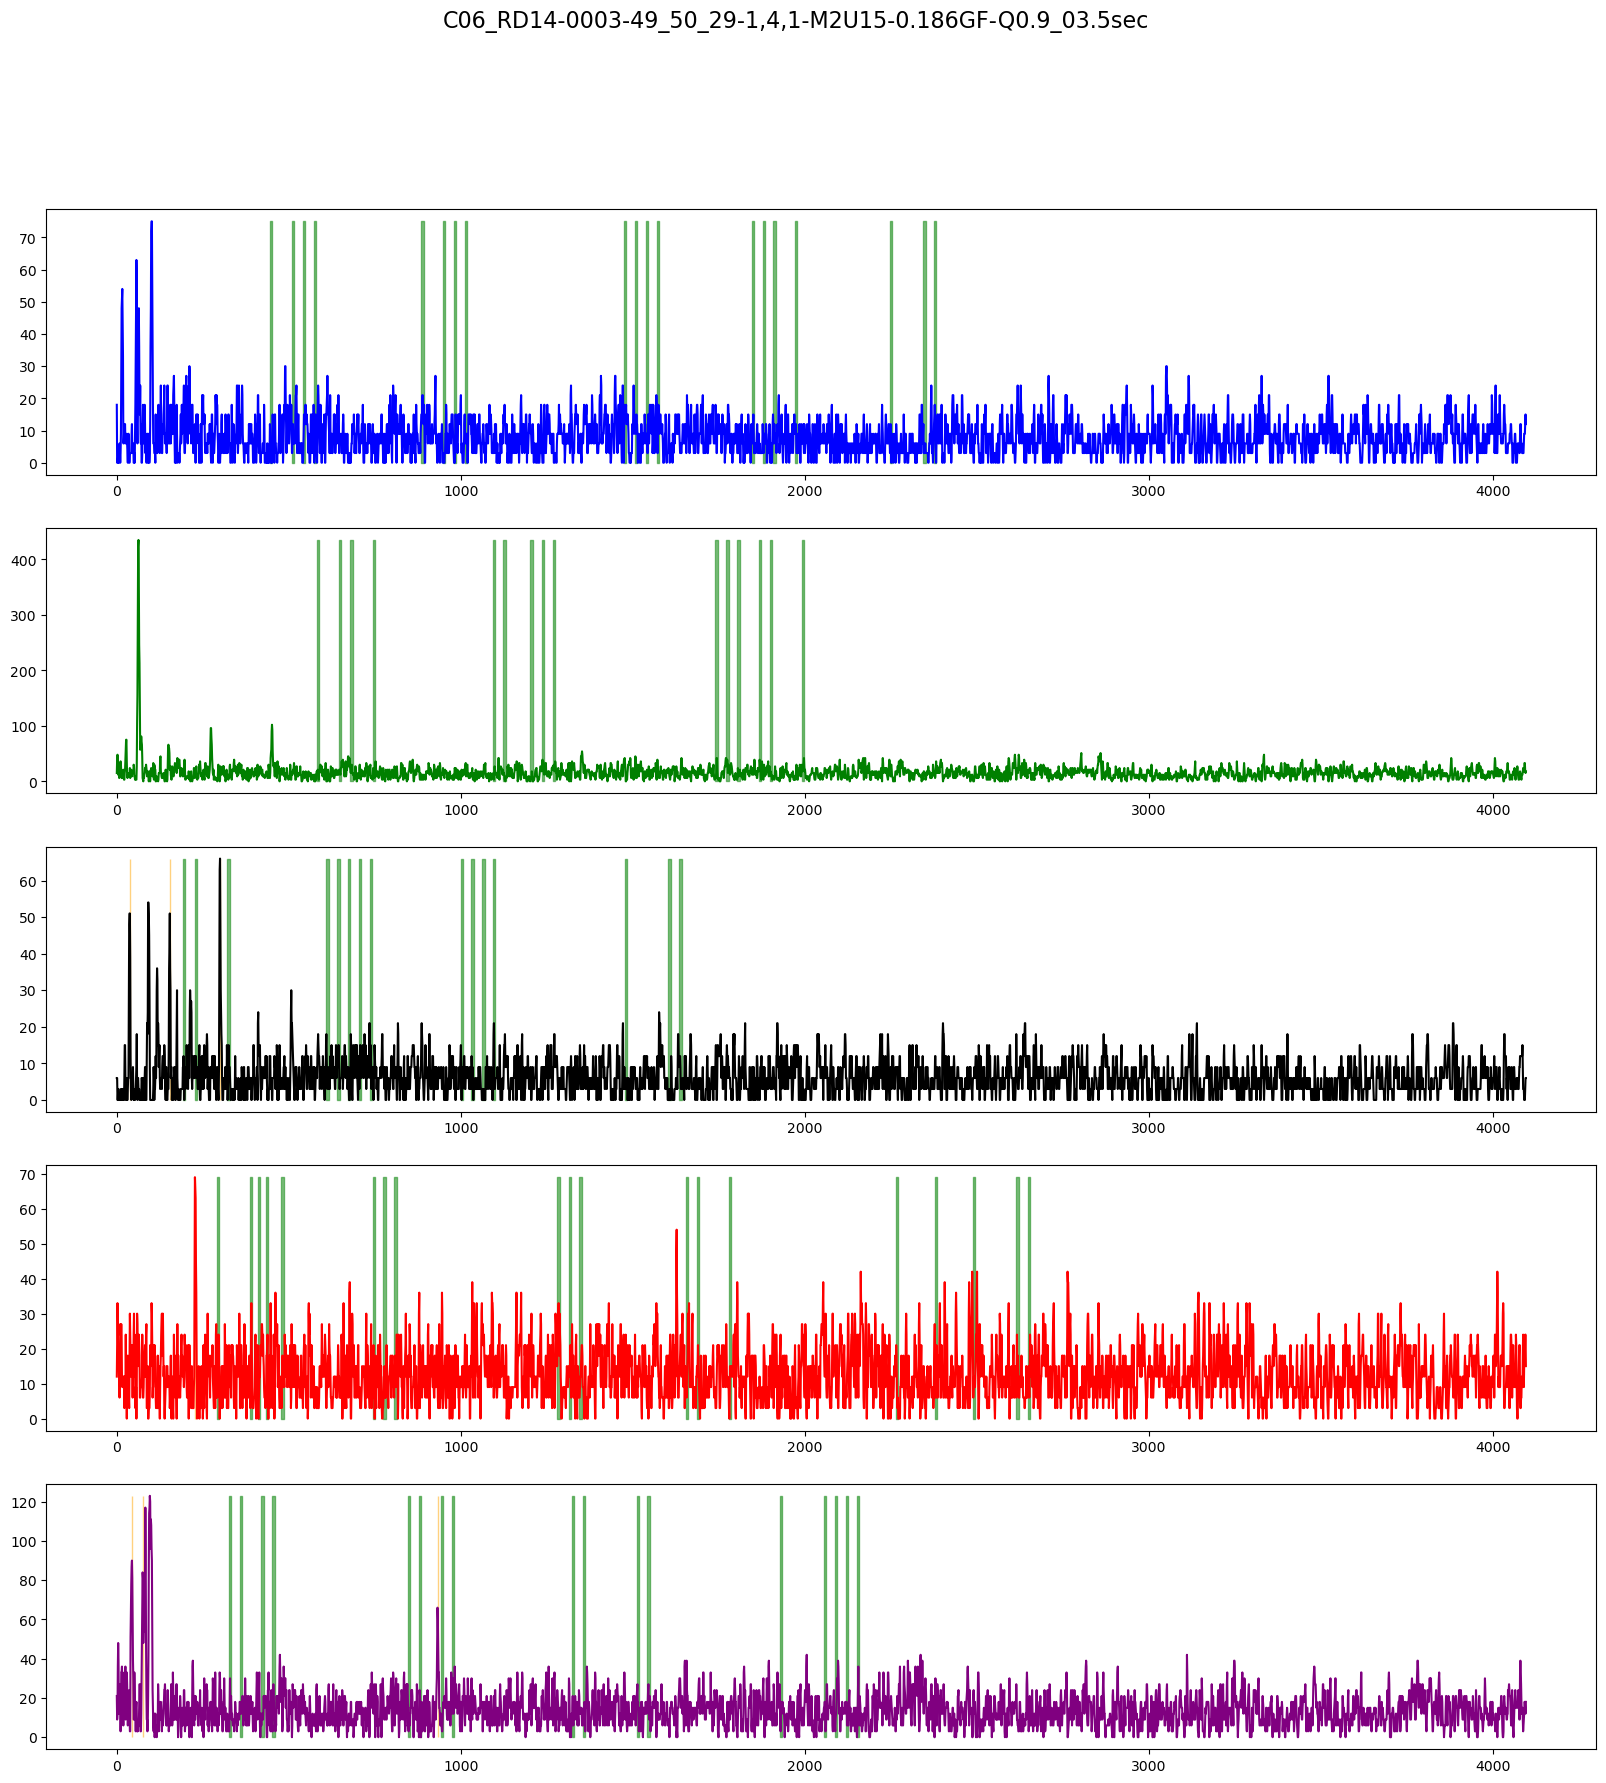

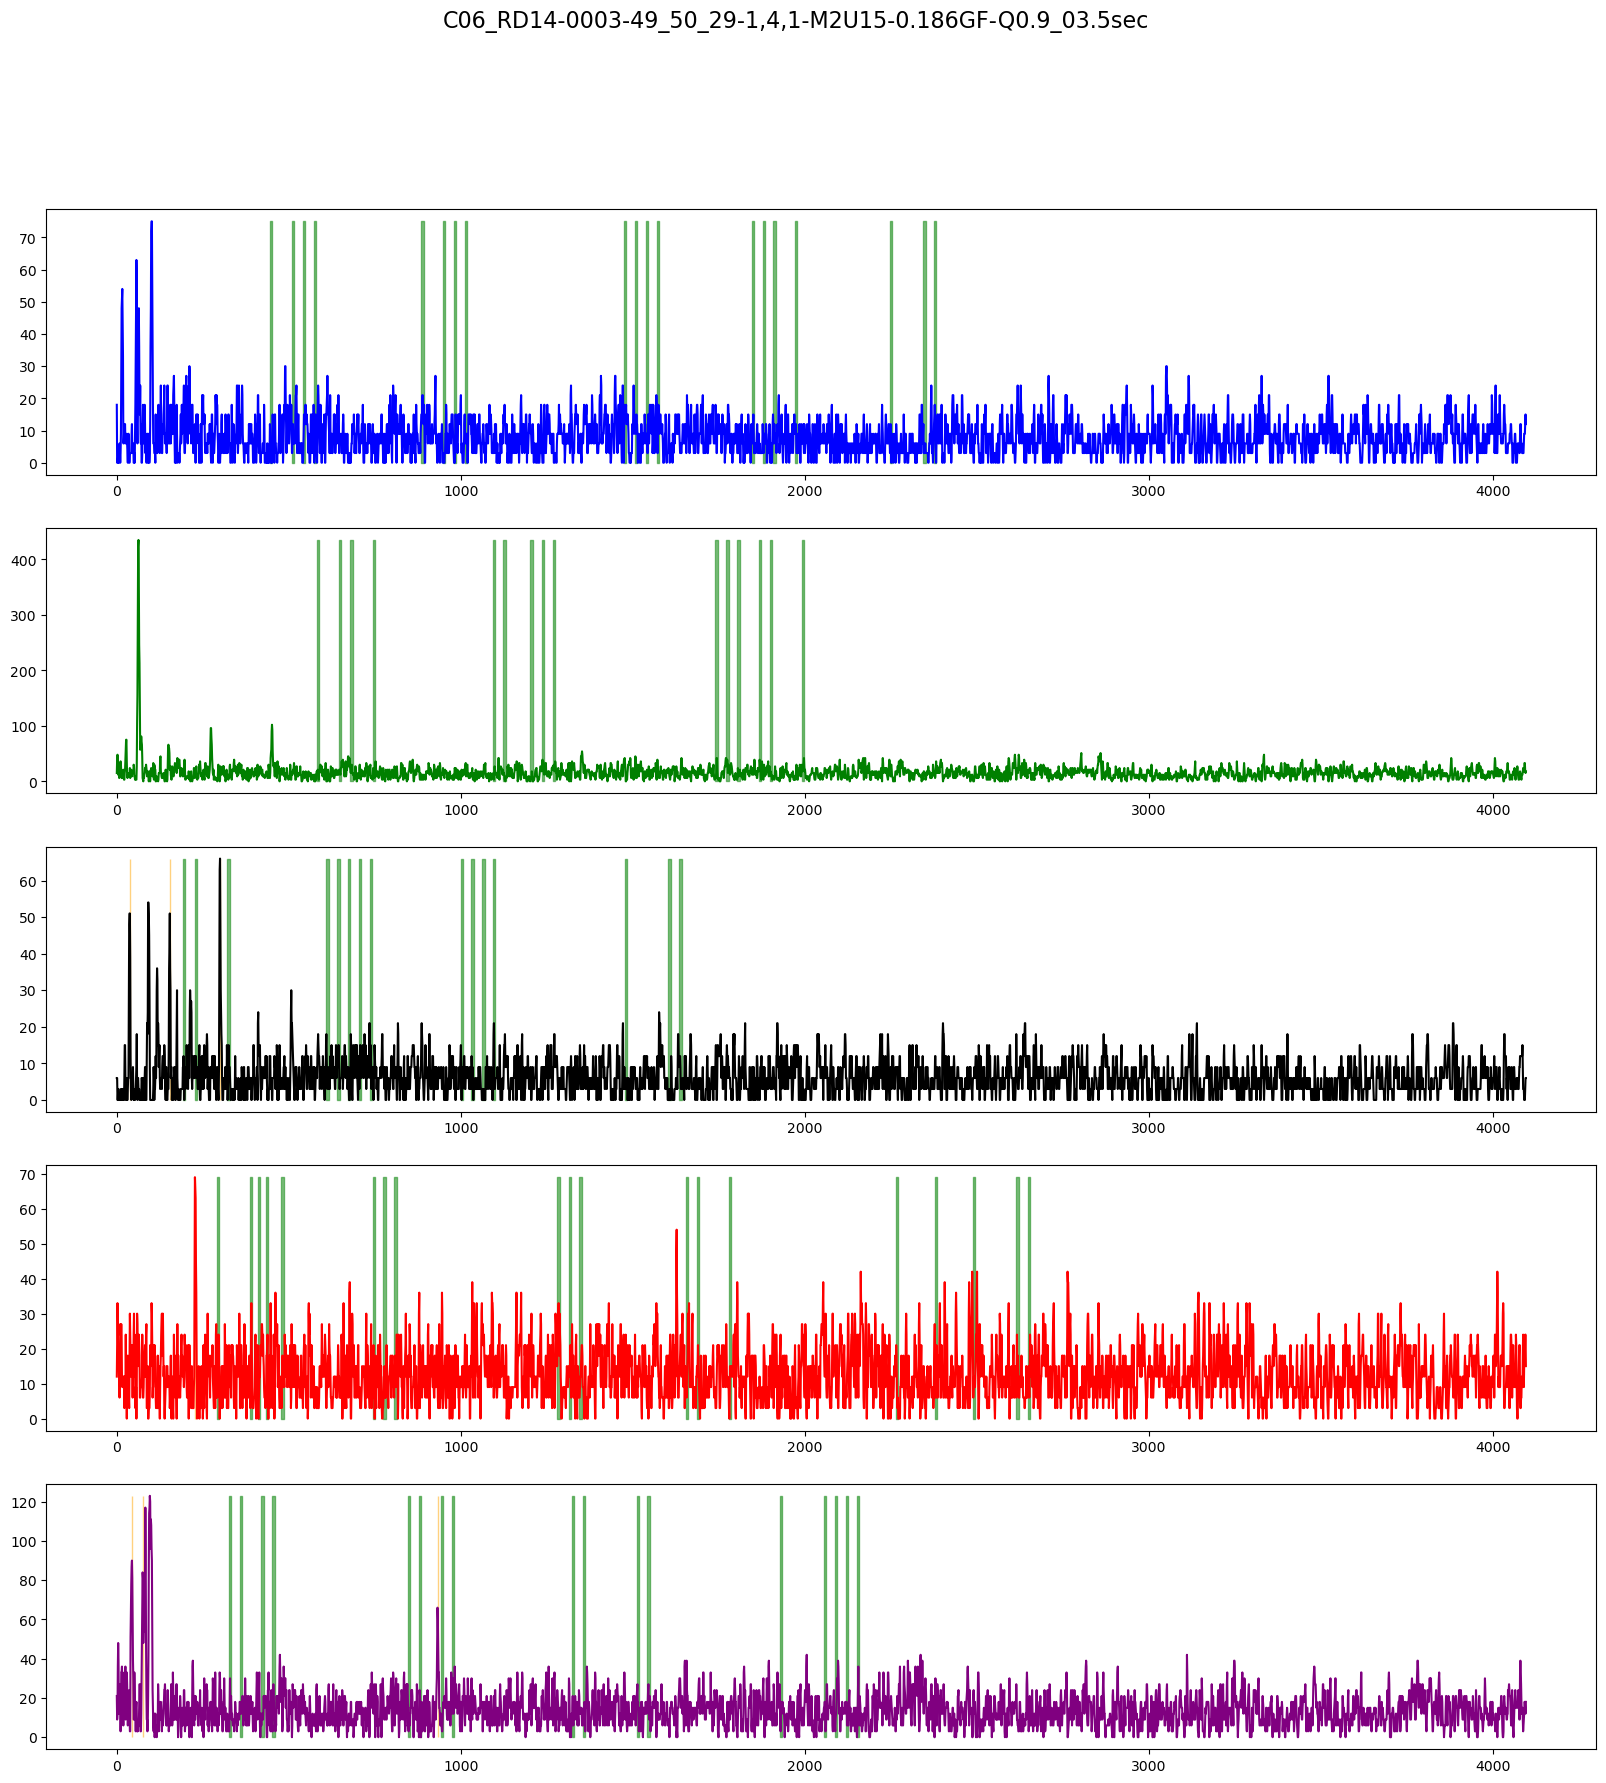

In [ ]:
plot_profile(hid_images=[hardest_files[0]['image']], predictions=[hardest_files[0]['prediction']])
plot_profile_markers(hid_images=[image])